<a href="https://colab.research.google.com/github/Vbhhacl/Data-Science-Practicals/blob/main/Practical4_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset
(https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various
houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

boston = pd.DataFrame(data)
boston.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
boston['MEDV'] = target

df = boston.copy()
df

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1035/4180480671.py:11: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.isnull()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64
TAX,float64


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: >

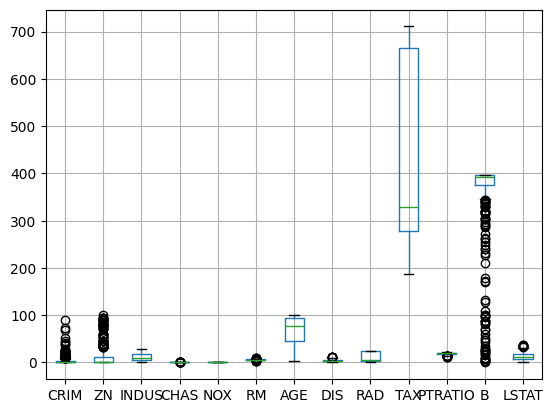

In [ ]:
column=["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT"]
df.boxplot(column)

In [ ]:
df["CRIM"]=df["CRIM"].fillna(df["CRIM"].mean())

In [ ]:
df["ZN"]=df["ZN"].fillna(df["ZN"].mean())

In [ ]:
df["INDUS"]=df["INDUS"].fillna(df["INDUS"].mean())

In [ ]:
df["CHAS"]=df["CHAS"].fillna(df["CHAS"].mean())

In [ ]:
df["AGE"]=df["AGE"].fillna(df["AGE"].mean())

In [ ]:
df["LSTAT"]=df["LSTAT"].fillna(df["LSTAT"].mean())

In [ ]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
df["RAD"]=df["RAD"].astype(float)

In [ ]:
df["TAX"]=df["TAX"].astype(float)

In [ ]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64
TAX,float64


In [ ]:
corr=df.corr()

In [ ]:
corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


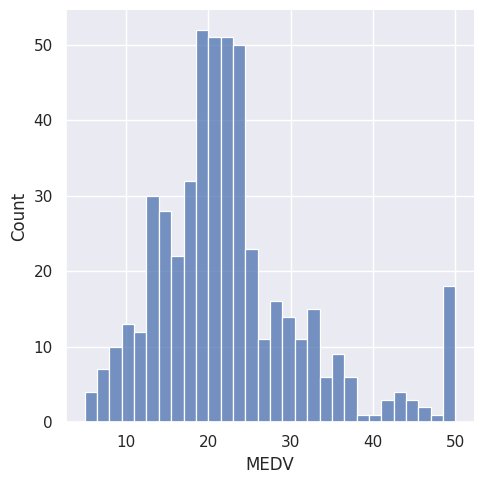

In [ ]:
sns.set(rc={'figure.figsize':(12,9)})
sns.displot(df["MEDV"],bins=30)
plt.show()

<Axes: >

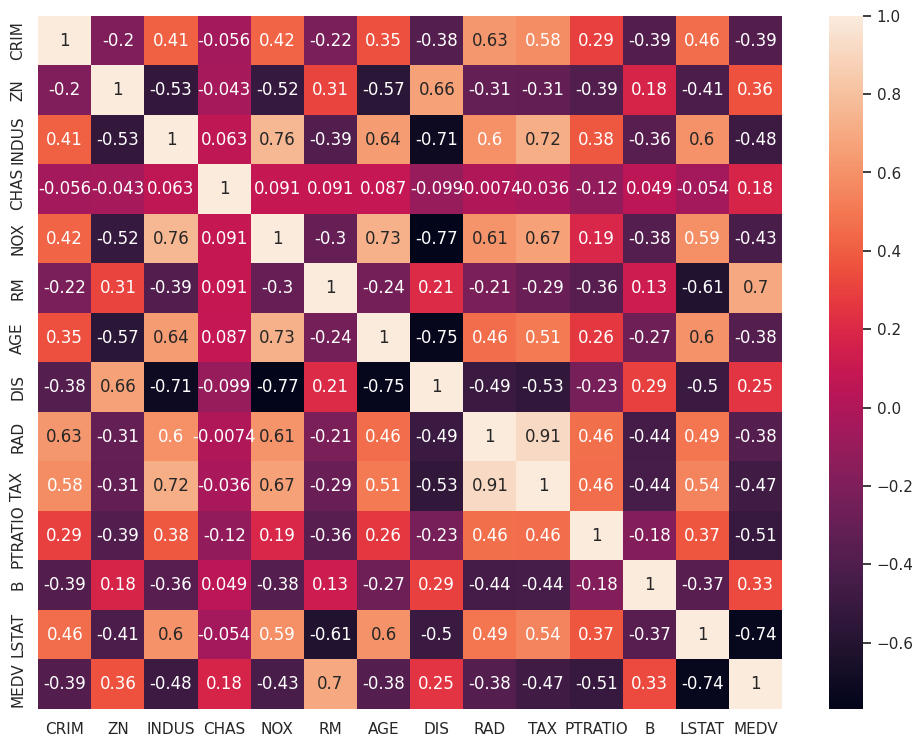

In [ ]:
sns.heatmap(corr,annot=True)

<Axes: >

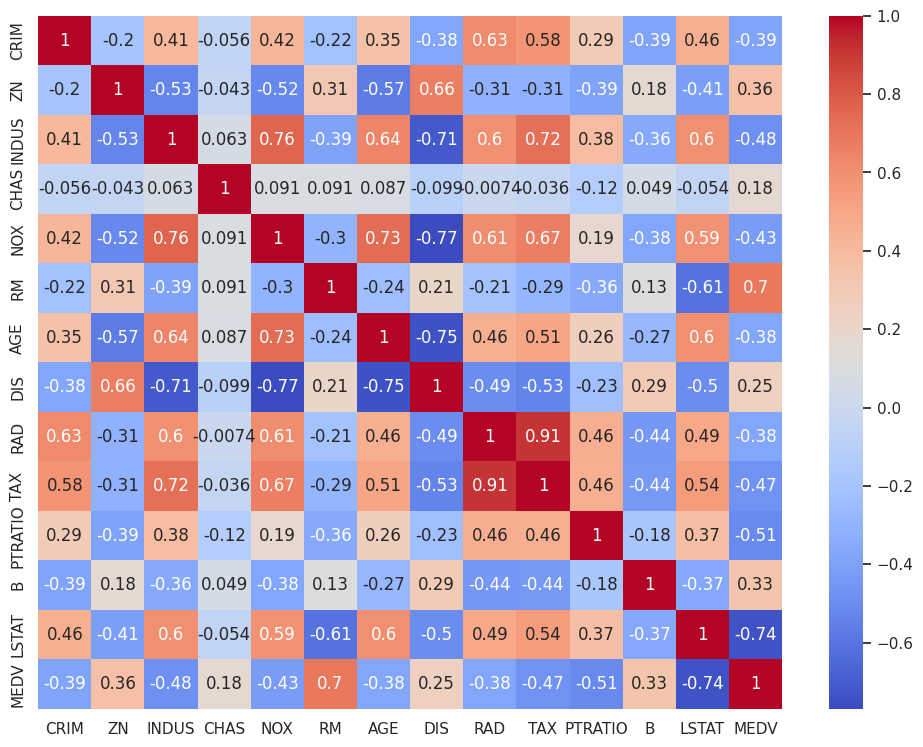

In [ ]:
sns.heatmap(corr,cmap="coolwarm",annot=True)

In [ ]:
X=df.drop(["MEDV"],axis=1)
y=df["MEDV"]

In [147]:
X_train, X_test, y_train, y_test= train_test_split(X , y, test_size=0.25, random_state=52, shuffle=True)

In [148]:
X_train.shape

(379, 13)

In [149]:
X_test.shape

(127, 13)

In [150]:
linear=LinearRegression()
linear.fit(X_train,y_train)
y_train_predict=linear.predict(X_train)
y_train_predict

array([25.33172236, 36.72047393, 13.78287654, 19.73011989, 38.11626486,
       30.54960531, 32.9120336 , 34.97000945, 24.59801682, 33.11243543,
       14.51180069, 27.17403778, -2.68252387, 20.84843871, 27.39944582,
       29.94073071, 15.95413252,  8.68681196, 17.80498207, 16.5934311 ,
       23.0989152 , 18.17387639, 23.50371506, 15.61367288, 30.83099951,
       21.44429258, 25.15706981, 31.20231862, 16.3137264 , 14.6679491 ,
       18.25585853, 30.79148535, 28.93807369, 30.30524652, 11.63936673,
       15.86555964,  7.36706234, 17.86875026, 22.35297423, 25.79876684,
       14.24358096, 13.31326517, 23.83643376, 27.3449063 , 16.98899614,
       25.39635204, 26.88111953, 31.62045346, 16.34370048, 11.5697919 ,
       26.34339573, 23.71862394, 27.90143652, 15.63272598, 30.05645669,
       22.14792278, 15.34598808, 20.36768135, 20.39173625, 13.38735365,
       22.42400914, 18.51791659, 20.50135106, 27.88445271, 15.3171975 ,
       24.62635723, 20.84310215, 28.50721496, 26.78908783, 18.77

In [151]:
linear.coef_

array([-7.20177602e-02,  3.36926907e-02,  2.66095327e-02,  4.95922664e-01,
       -1.48475871e+01,  3.83640855e+00, -4.44611467e-03, -1.30295620e+00,
        2.82193229e-01, -1.40520887e-02, -9.96301500e-01,  1.04567396e-02,
       -4.77043839e-01])

In [152]:
linear.intercept_

np.float64(35.11760491898628)

In [153]:
y_test_predict=linear.predict(X_test)
y_test_predict

array([25.90342437, 19.34943464, 22.3491831 , 25.16083944, 15.13160315,
       36.50320429, 28.85685159, 28.0265548 , 11.84833166, 17.82887788,
       24.8988381 , 13.99935966, 20.11021856, 28.06680436, 18.60882578,
       21.39112939, 38.02835123, 32.59717824, 18.87402215, 23.99381572,
       17.06310714, 32.48931981, 16.12095476, 20.57013294, 14.33000605,
       18.47114899, 10.14321023, 13.04287109,  6.96076003, 15.45214829,
       17.96236275, 12.62839781, 13.40692462,  8.95015365, 27.76663257,
       35.02857204, 16.49256349, 26.48269422, 22.54421799, 22.24775567,
       15.26652707, 32.41643235, 20.75973987, 14.26450685, 30.84143384,
       32.61661822, 17.4737686 , 30.81504959, 13.40716276, 21.8070664 ,
       19.26272856, 20.13337482, 11.91060049, 23.25267924, 26.43189046,
       19.64622184, 13.76978194,  6.88793975, 32.53426083, 32.17392222,
       20.62751024, 17.49167892, 20.60480673, 29.32603404, 28.35331162,
       25.06987649, 12.17946382, 24.57291125, 19.19286103, 35.91

In [154]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [155]:
r2=r2_score(y_test,y_test_predict)
mse=mean_squared_error(y_test,y_test_predict)
mae=mean_absolute_error(y_test,y_test_predict)
rmse=np.sqrt(mse)

In [156]:
print("R2 ",r2)
print("MSE ",mse)
print("MAE ",mae)
print("RMSE ",rmse)

R2  0.7643223132223181
MSE  25.622300053937547
MAE  3.229863135900322
RMSE  5.061847494140608


Text(0, 0.5, 'Predicted_values')

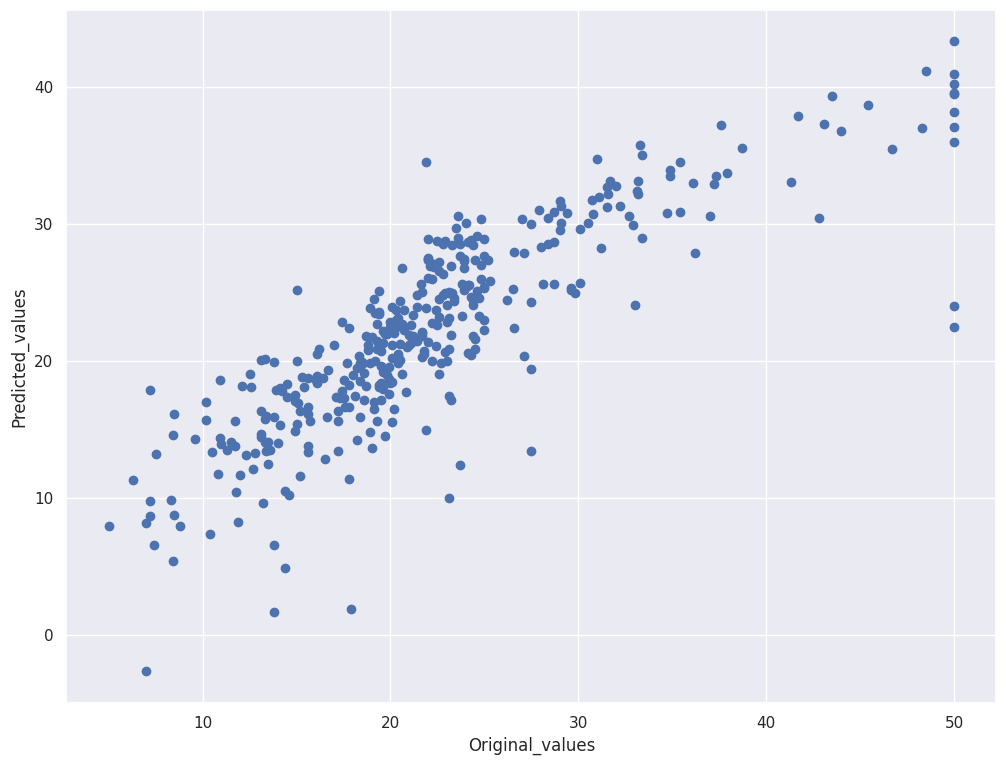

In [157]:
plt.scatter(y_train,y_train_predict)
plt.xlabel("Original_values")
plt.ylabel("Predicted_values")

Text(0, 0.5, 'Predicted_values')

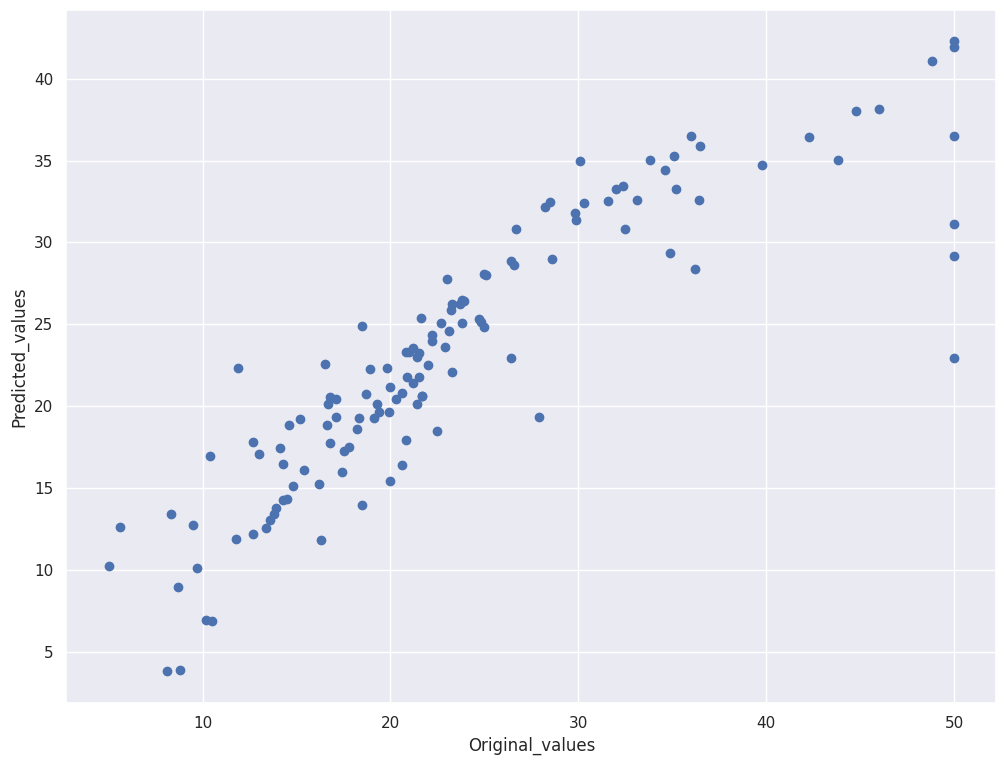

In [158]:
plt.scatter(y_test,y_test_predict)
plt.xlabel("Original_values")
plt.ylabel("Predicted_values")

In [159]:
linear.score(X_test,y_test)

0.7643223132223181

In [160]:
column=["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT"]

<Axes: >

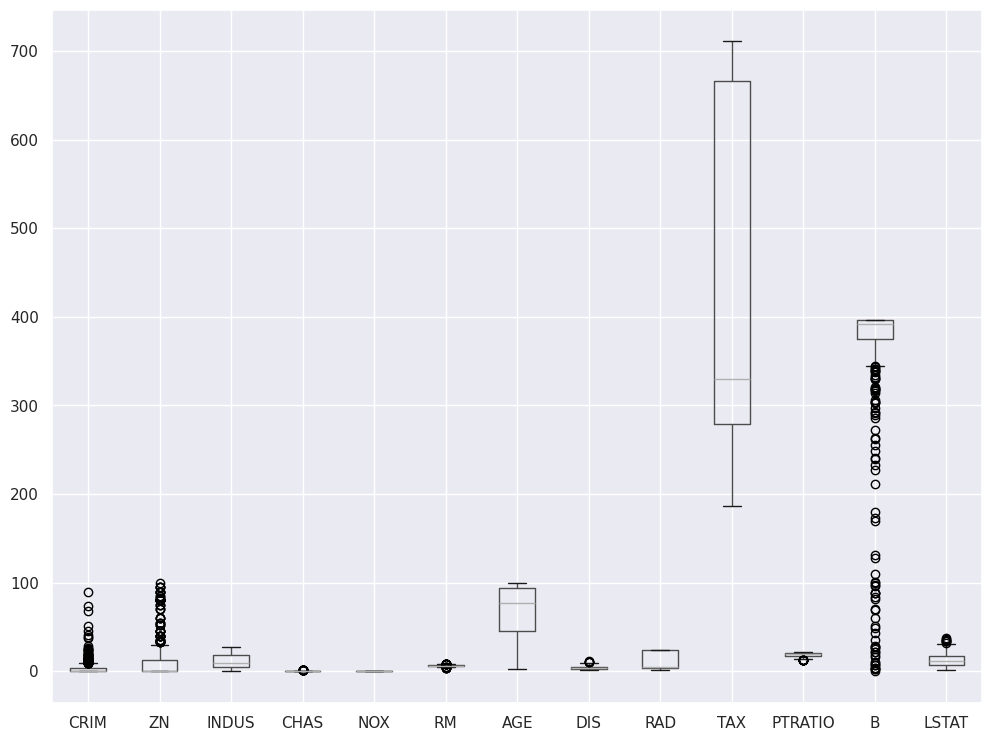

In [161]:
df.boxplot(column)

In [162]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

In [163]:
skew_val = df['CRIM'].skew()
kurtosis_val = df['CRIM'].kurtosis()

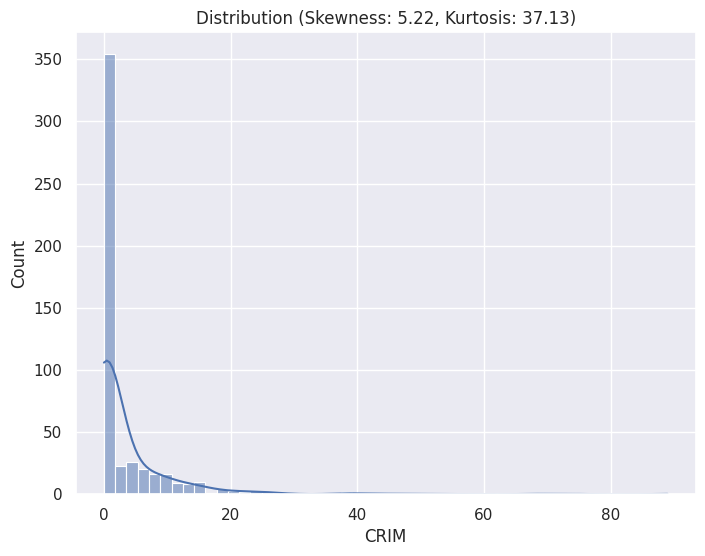

In [164]:
plt.figure(figsize=(8, 6))
sns.histplot(df['CRIM'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

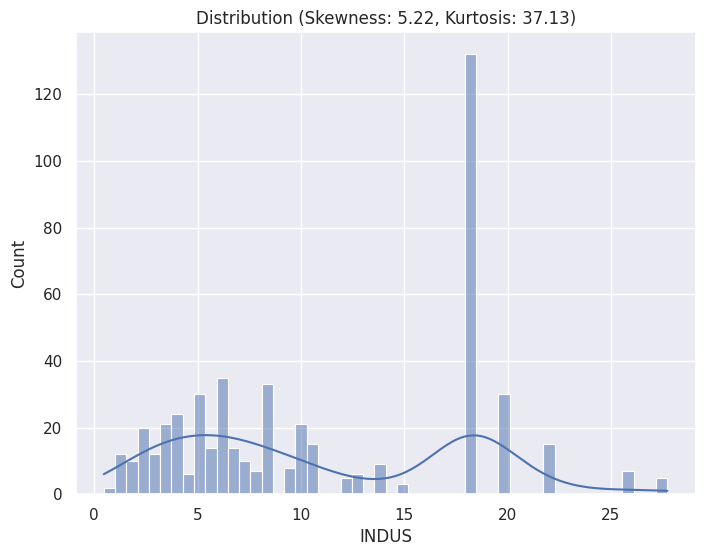

In [165]:
plt.figure(figsize=(8, 6))
sns.histplot(df['INDUS'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

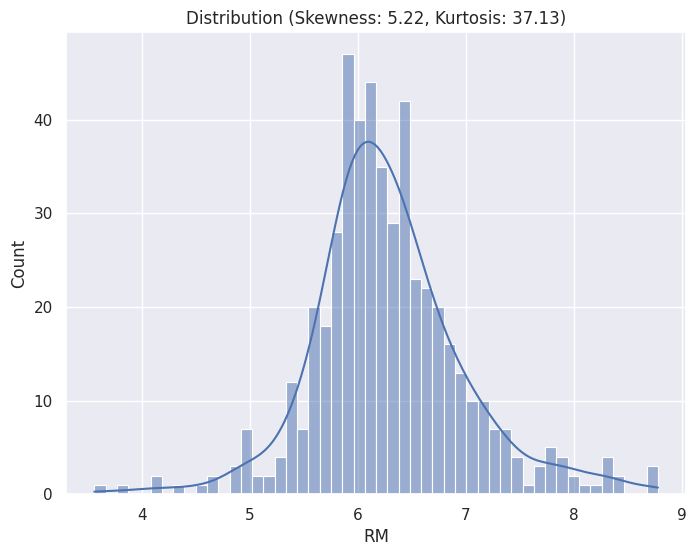

In [166]:
plt.figure(figsize=(8, 6))
sns.histplot(df['RM'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

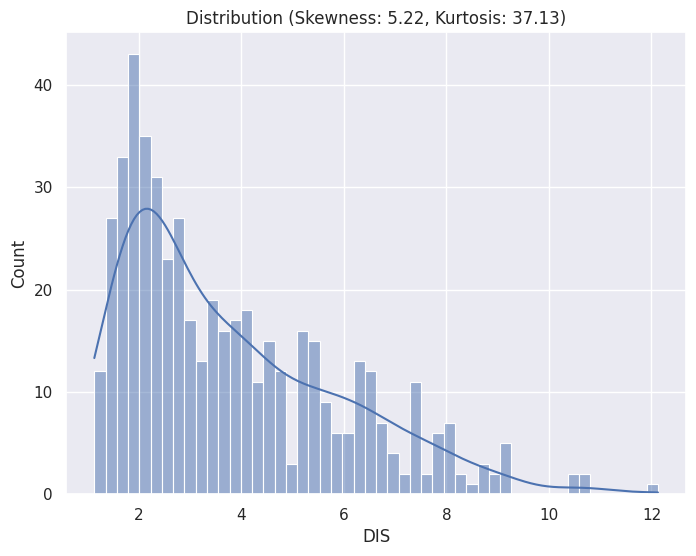

In [167]:
plt.figure(figsize=(8, 6))
sns.histplot(df['DIS'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")
plt.show()

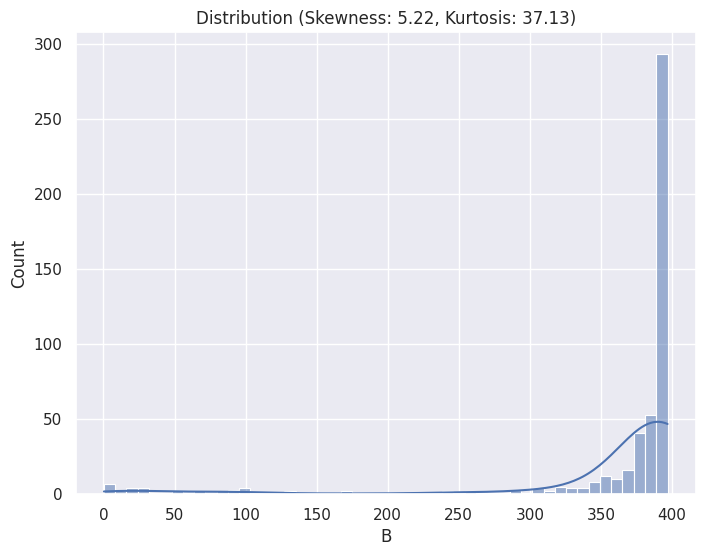

In [168]:
plt.figure(figsize=(8, 6))
sns.histplot(df['B'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

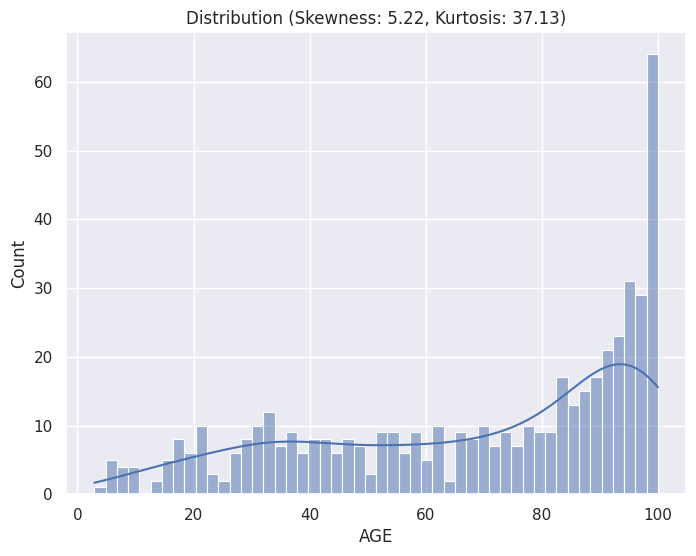

In [169]:
plt.figure(figsize=(8, 6))
sns.histplot(df['AGE'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

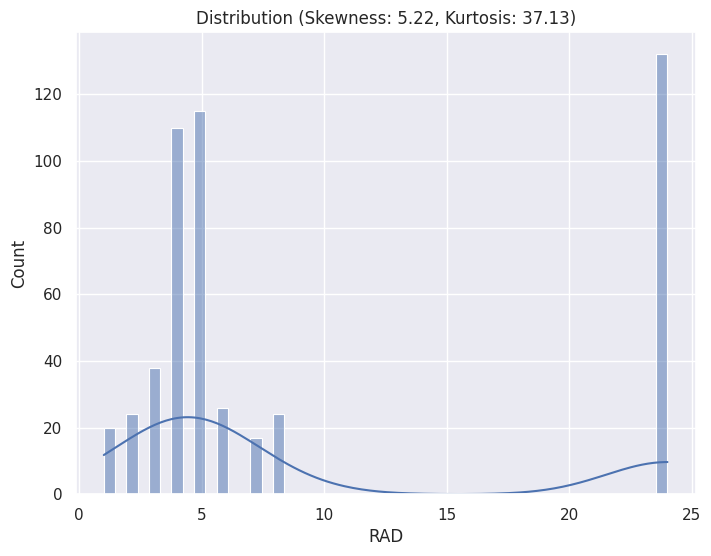

In [170]:
plt.figure(figsize=(8, 6))
sns.histplot(df['RAD'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

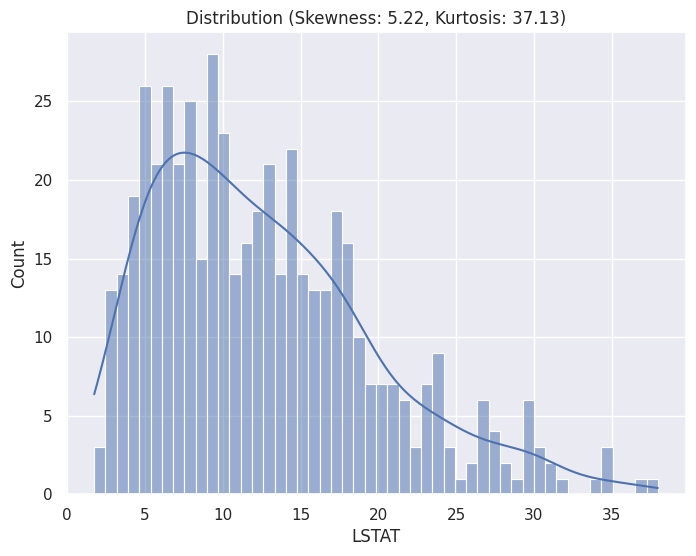

In [171]:
plt.figure(figsize=(8, 6))
sns.histplot(df['LSTAT'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

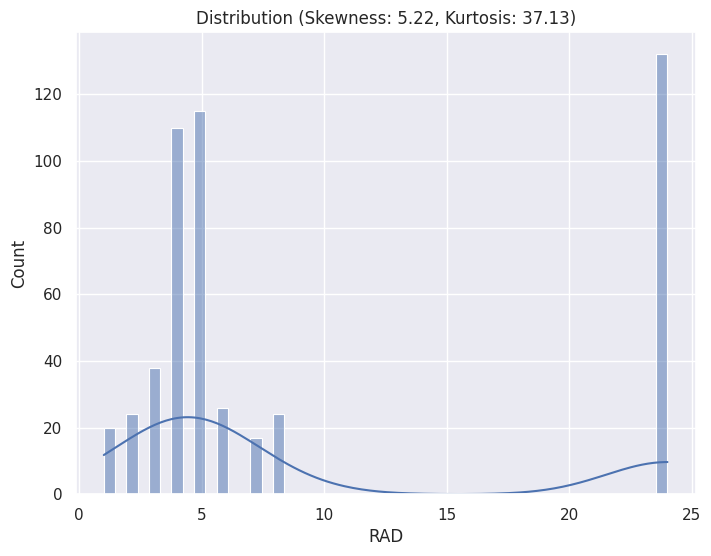

In [172]:
plt.figure(figsize=(8, 6))
sns.histplot(df['RAD'], kde=True, bins=50)
plt.title(f"Distribution (Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f})")

plt.show()

Text(0.5, 0, 'PRICE DESTRIBUTION')

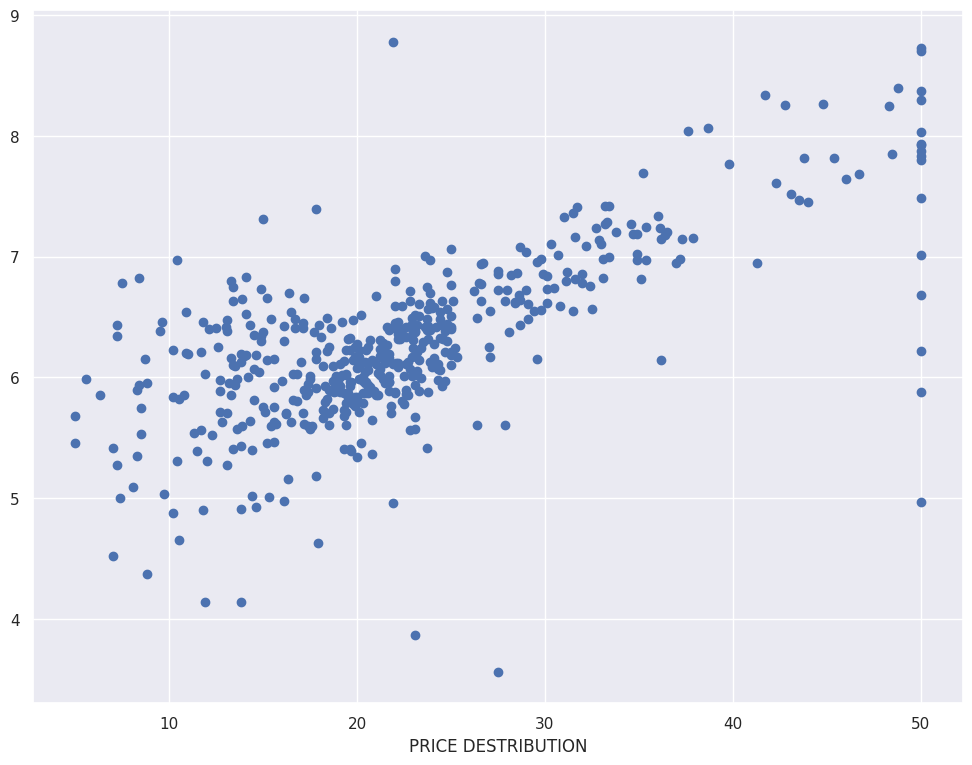

In [173]:
plt.scatter(df['MEDV'],df['RM'])
plt.xlabel("PRICE DESTRIBUTION")

Text(0.5, 0, 'PRICE DESTRIBUTION')

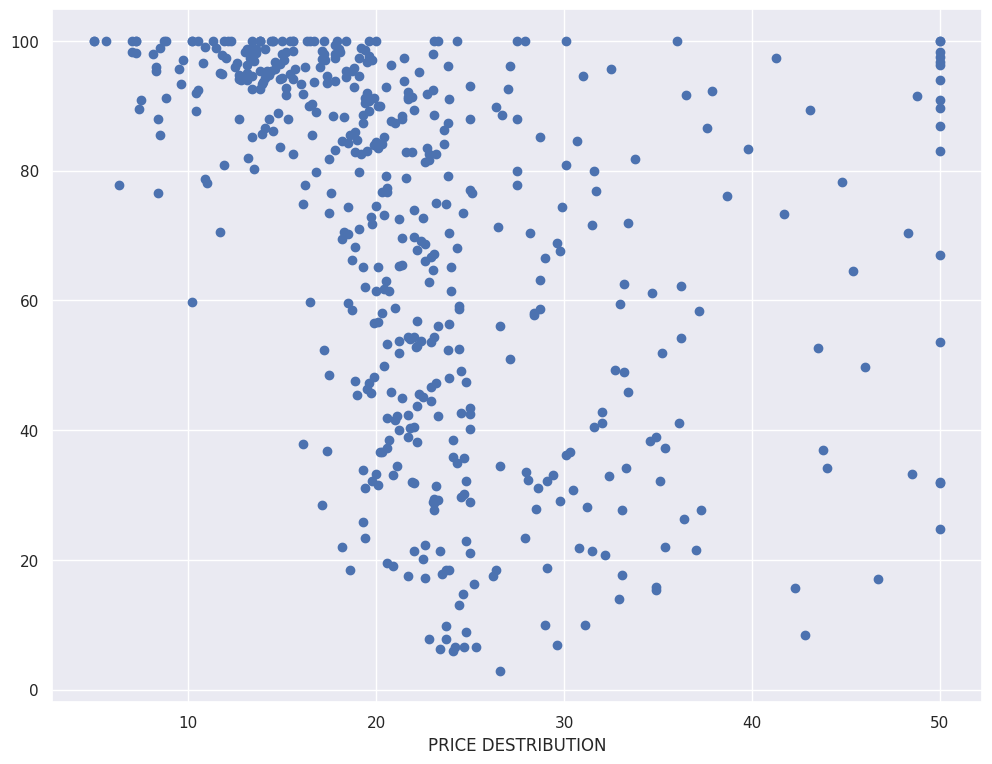

In [174]:
plt.scatter(df['MEDV'],df['AGE'])
plt.xlabel("PRICE DESTRIBUTION")

Text(0.5, 0, 'PRICE DESTRIBUTION')

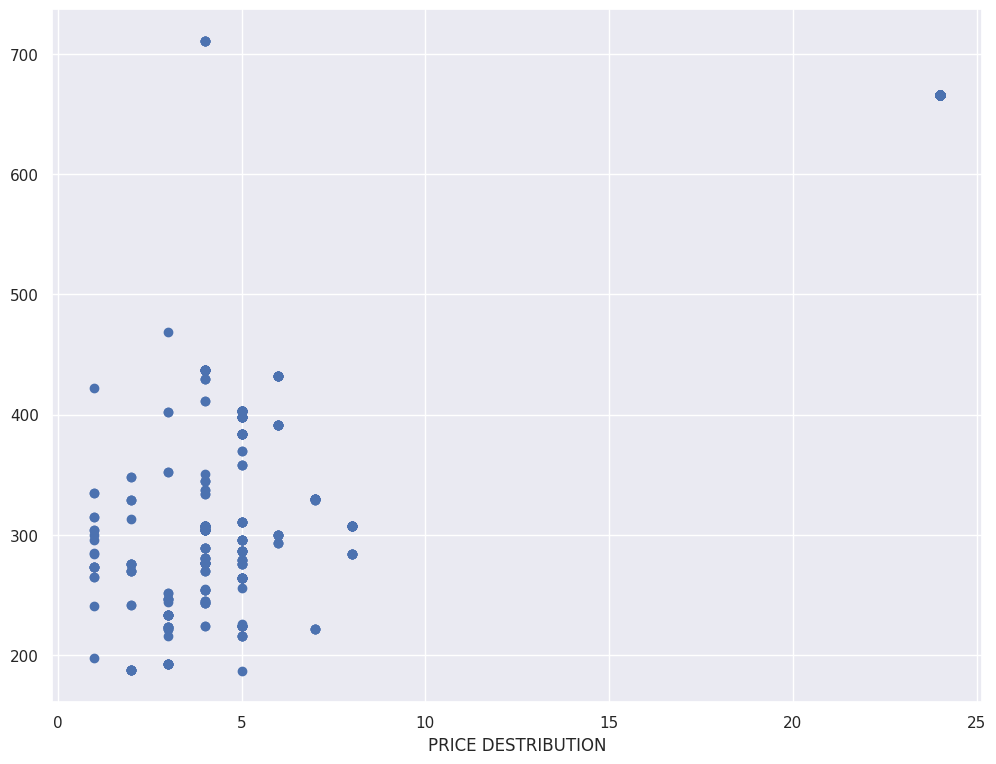

In [175]:
plt.scatter(df['RAD'],df['TAX'])
plt.xlabel("PRICE DESTRIBUTION")

Text(0.5, 0, 'PRICE DESTRIBUTION')

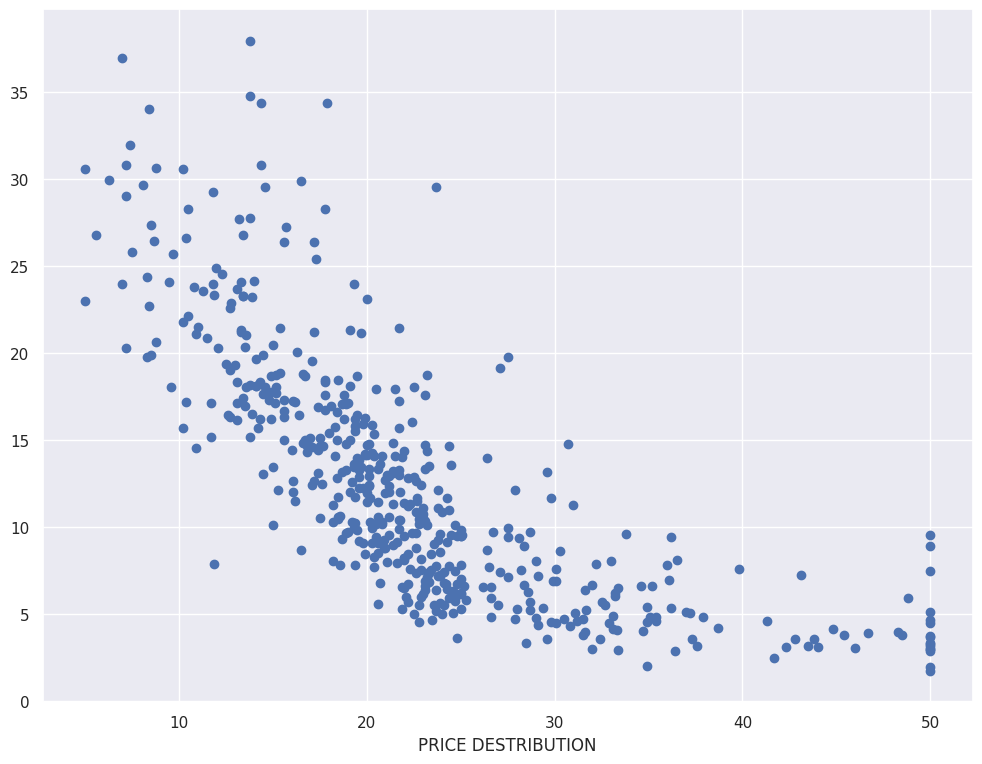

In [176]:
plt.scatter(df['MEDV'],df['LSTAT'])
plt.xlabel("PRICE DESTRIBUTION")

Text(0.5, 0, 'PRICE DESTRIBUTION')

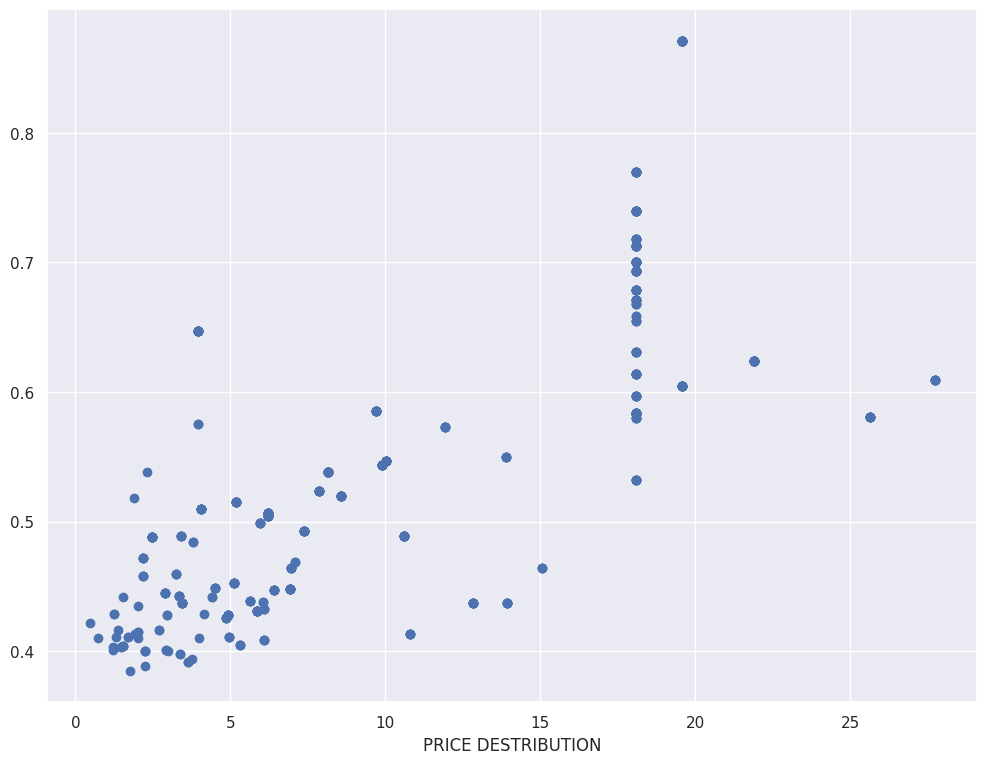

In [177]:
plt.scatter(df['INDUS'],df['NOX'])
plt.xlabel("PRICE DESTRIBUTION")

NameError: name 'df1' is not defined

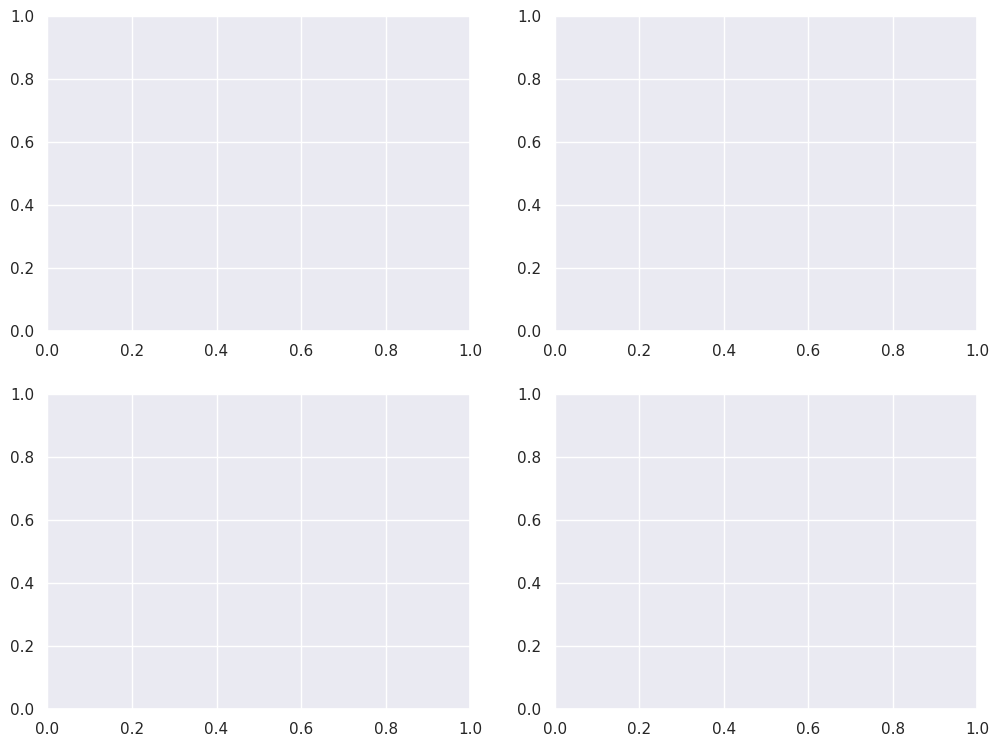

In [181]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=2)

df1.plot(ax=axes[0,0])
df2.plot(ax=axes[0,1])
